<div style="background-color:#c3faf6; color:#222222; border:3px solid #bee5eb; padding:12px 14px; border-radius:10px; margin:10px 0;">

# How Facial Recognition Bias Compounds Across Race and Gender as Subjects Age


**CS109b Group #103**:Jenni Arakaki, Laine Roper, Arian Nzioka
**Project #18**: 

Project Proposal: https://drive.google.com/file/d/1yRPxpvg4jQc8gwzPgP_ptiSU6Qs4qmL1/view

In [1]:
!pip install kagglehub
# Standard library
import os
import gc
import time
import warnings

# Numerical computing and data processing
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import Counter
import zipfile

# external utilities
import kagglehub
import hashlib

# Visualization
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from torchvision import transforms

# UMAP
#import umap
from tqdm import tqdm
import umap
from umap import UMAP

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Suppress warnings
warnings.filterwarnings('ignore')

### Downloading/Accessing data:
1) Download data from https://www.kaggle.com/datasets/jangedoo/utkface-new.
2) kagglehub library downloads and stores data in `./cache` directory for reproducibility

In [3]:
path = kagglehub.dataset_download("jangedoo/utkface-new")
utk_path = next(Path(path).rglob("UTKFace"))

print("Path Exists  :", utk_path.exists())

print(f"\nDataset downloaded to:", utk_path)

Path Exists  : True

Dataset downloaded to: /shared/home/lar160/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/UTKFace


In [4]:
# put image paths into Dataset, make all RGB, count how many
class FlatImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.files   = [f for f in self.img_dir.rglob("*")
                        if f.name.endswith(".jpg")
                        or f.name.endswith(".jpeg")
                        or f.name.endswith(".png")]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.files[idx].name

dataset = FlatImageDataset(utk_path)

size = 0
img_count = 0
for dirpath, dirnames, filenames in os.walk(utk_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        size += os.path.getsize(fp)
        img_count += 1

print(f"Number of images : {img_count}")
print(f"Size on disk   : {size / (1024**2):.2f} MB")

Number of images : 23708
Size on disk   : 114.43 MB


### Search for and Remove Duplicate Images

In [5]:
print("Hashing images...")

def hash_image(img):
    """Generate MD5 hash from image pixels (fingerprint of image)."""
    return hashlib.md5(np.array(img).tobytes()).hexdigest()

# --- compute hashes directly from image files from Dataset object ---
hashes = []
images = []

for p in dataset.files:
    img = Image.open(p).convert("RGB")
    images.append(img)
    hashes.append(hash_image(img))

df = pd.DataFrame({
    "path": dataset.files,
    "image": images,
    "hash": hashes
})

# --- duplicate analysis ---
n_before = len(df)
dup_mask = df.duplicated(subset='hash', keep='first')
num_removed = dup_mask.sum()

print(f"Total images before : {n_before}")
print(f"Duplicate images removed : {num_removed}")

# --- keep only first occurrence of each image ---
df = df.drop_duplicates(subset='hash', keep='first').reset_index(drop=True)

print("\nDataset cleaned.")
print(f"Non-duplicated dataset size : {len(df)}")

Hashing images...
Total images before : 23708
Duplicate images removed : 390

Dataset cleaned.
Non-duplicated dataset size : 23318


In [6]:
# Build a labeled UTKFace dataset by parsing age/gender/race from filenames, 
#loading images into a DataFrame, and wrapping it in a PyTorch Dataset with 
#tensor conversion for model training
def parse_utk_filename(filename):
    parts = filename.split("_")

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
        return age, gender, race
    except:
        return None  # invalid file

class DFDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = row['image']
        age    = row['age']
        gender = row['gender']
        race   = row['race']

        if self.transform:
            img = self.transform(img)

        #make friendly for pytorch
        return img, torch.tensor(age), torch.tensor(gender), torch.tensor(race)
        
rows = []

for p in dataset.files:
    parsed = parse_utk_filename(p.name)

    # skip bad files
    if parsed is None:
        continue

    age, gender, race = parsed

    img = Image.open(p).convert("RGB")

    rows.append({
        "image": img,
        "age": age,
        "gender": gender,
        "race": race,
        "hash": hash_image(img)
    })

df = pd.DataFrame(rows)
transform = transforms.Compose([
    transforms.ToTensor(),
])

clean_dataset = DFDataset(df, transform=transform)

print(f"Clean dataset size: {len(clean_dataset):,} images")

Clean dataset size: 23,705 images


## Baseline Model ResNet Training

### Train val test split

Stratifying so each the proportions of each split match the proportions in the entire dataset, no biased training in that sense.

Because some fine-grained age × race × gender subgroups contained too few samples for reliable stratified splitting, we stratified by race and gender only, while reserving age bins for downstream fairness evaluation.

Ages are binned to specifically look at the effect of fewer images of teens.

In [7]:
labels = ["0_5",      # infants / toddlers
          "5_13",     # children
          "13_20",    # teens
          "21_40",
          "41_60",
          "61_80",
          "80_plus"
]

df["eval_age_bin"] = pd.cut(
    df["age"],
    bins = [0, 5, 13, 20, 40, 60, 80, 120],
    labels = labels,
    include_lowest=True
)

# simple stratification key
df["stratify_key"] = (
    df["race"].astype(str) + "_" +
    df["gender"].astype(str) + "_"
)

# remove very tiny groups if stratification breaks
valid_keys = df["stratify_key"].value_counts()
valid_keys = valid_keys[valid_keys >= 2].index
df_split = df[df["stratify_key"].isin(valid_keys)].copy()

train_df, temp_df = train_test_split(
    df_split,
    test_size=0.30,
    random_state=42,
    stratify=df_split["stratify_key"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["stratify_key"]
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 16593
Validation size: 3556
Test size: 3556


In [8]:
class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # already a PIL image
        image = row["image"]

        if self.transform:
            image = self.transform(image)

        age = torch.tensor(row["age"], dtype=torch.float32)
        gender = torch.tensor(row["gender"], dtype=torch.float32)

        race = str(row["race"])
        age_bin = str(row["eval_age_bin"])

        return image, age, gender, race, age_bin

In [9]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# dataloaders
train_dataset = UTKFaceDataset(train_df, transform=train_transform)
val_dataset = UTKFaceDataset(val_df, transform=val_transform)
test_dataset = UTKFaceDataset(test_df, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)


class MultiTaskResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.age_head = nn.Linear(in_features, 1)
        self.gender_head = nn.Linear(in_features, 1)

    def forward(self, x, return_features=False):
        features = self.backbone(x)

        age_pred = self.age_head(features).squeeze(1)
        gender_logit = self.gender_head(features).squeeze(1)

        if return_features:
            return age_pred, gender_logit, features

        return age_pred, gender_logit


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)
    
def extract_embeddings(model, loader, device):
    model.eval()

    embeddings = []
    age_preds = []
    gender_preds = []
    age_bins = []
    races = []
    genders = []

    with torch.no_grad():
        for images, ages, gender, race, age_bin in loader:
            images = images.to(device)

            age_pred, gender_logit, features = model(images, return_features=True)

            gender_pred = (torch.sigmoid(gender_logit) >= 0.5).float()

            embeddings.append(features.cpu())
            age_preds.append(age_pred.cpu())
            gender_preds.append(gender_pred.cpu())

            age_bins.extend(age_bin)
            races.extend(race)
            genders.extend(gender)

    return {
        "embeddings": torch.cat(embeddings),
        "age_pred": torch.cat(age_preds),
        "gender_pred": torch.cat(gender_preds),
        "age_bin": np.array(age_bins),
        "race": np.array(races),
        "gender": np.array(genders)
    }

def train_one_epoch(model, loader, optimizer, age_criterion, gender_criterion, device):
    model.train()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0

    for images, ages, genders, _, _ in tqdm(loader, desc="Training"):
        images = images.to(device)
        ages = ages.to(device)
        genders = genders.to(device)

        optimizer.zero_grad()

        age_pred, gender_logit = model(images)

        age_loss = age_criterion(age_pred, ages)
        gender_loss = gender_criterion(gender_logit, genders)

        loss = age_loss + gender_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_age_loss += age_loss.item() * images.size(0)
        total_gender_loss += gender_loss.item() * images.size(0)

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n
    }

def evaluate(model, loader, age_criterion, gender_criterion, device):
    model.eval()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0

    all_age_preds = []
    all_ages = []
    all_gender_preds_list = []
    all_genders = []

    with torch.no_grad():
        for images, ages, genders, _, _ in loader:
            images = images.to(device)
            ages = ages.to(device)
            genders = genders.to(device)

            age_pred, gender_logit = model(images)

            age_loss = age_criterion(age_pred, ages)
            gender_loss = gender_criterion(gender_logit, genders)
            loss = age_loss + gender_loss

            total_loss += loss.item() * images.size(0)
            total_age_loss += age_loss.item() * images.size(0)
            total_gender_loss += gender_loss.item() * images.size(0)

            gender_preds = (torch.sigmoid(gender_logit) >= 0.5).float()

            all_age_preds.append(age_pred.cpu())
            all_ages.append(ages.cpu())
            all_gender_preds_list.append(gender_preds.cpu())
            all_genders.append(genders.cpu())

    # safety check (prevents silent crashes)
    if len(all_gender_preds_list) == 0:
        raise RuntimeError("No validation predictions collected. Check DataLoader.")

    all_age_preds = torch.cat(all_age_preds)
    all_ages = torch.cat(all_ages)
    all_gender_preds = torch.cat(all_gender_preds_list)
    all_genders = torch.cat(all_genders)

    age_mae = torch.mean(torch.abs(all_age_preds - all_ages)).item()
    gender_acc = (all_gender_preds == all_genders).float().mean().item()

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n,
        "age_mae": age_mae,
        "gender_acc": gender_acc
    }
    
def compute_group_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    acc = (tp + tn) / len(y_true)
    fpr = fp / (fp + tn + 1e-8)
    fnr = fn / (fn + tp + 1e-8)

    return acc, fpr, fnr

def flatten_outputs(outputs):
    return {
        "race": to_numpy(outputs["race"]),
        "age_bin": to_numpy(outputs["age_bin"]),
        "gender": to_numpy(outputs["gender"]),
        "gender_pred": to_numpy(outputs["gender_pred"])
    }

def evaluate_fairness(outputs, attribute, label="gender"):
    results = {}

    y_true = outputs[label]
    y_pred = outputs[f"{label}_pred"]

    for group in np.unique(outputs[attribute]):
        mask = outputs[attribute] == group

        acc, fpr, fnr = compute_group_metrics(
            y_true[mask],
            y_pred[mask]
        )

        results[group] = {"acc": acc, "fpr": fpr, "fnr": fnr}

    return results

def fairness_gaps(group_metrics):
    accs = [v["acc"] for v in group_metrics.values()]
    fprs = [v["fpr"] for v in group_metrics.values()]
    fnrs = [v["fnr"] for v in group_metrics.values()]

    return {
        "Δaccuracy": max(accs) - min(accs),
        "ΔFPR": max(fprs) - min(fprs),
        "ΔFNR": max(fnrs) - min(fnrs),
        "worst_group_acc": min(accs)
    }

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_model = MultiTaskResNet().to(device)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)

num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": []
}

best_val_mae = float("inf")
best_gender_acc = 0.0

start_time = time.time()


# =========================
# TRAINING LOOP
# =========================
print("Starting training loop...")
for epoch in range(num_epochs):
    print("Epoch started")

    # ---- train ----
    train_metrics = train_one_epoch(
        resnet_model, train_loader, optimizer,
        age_criterion, gender_criterion, device
    )

    # ---- validate ----
    val_metrics = evaluate(
        resnet_model, val_loader,
        age_criterion, gender_criterion, device
    )

    # ---- log history ----
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_age_mae"].append(val_metrics["age_mae"])
    history["val_gender_acc"].append(val_metrics["gender_acc"])

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_metrics['loss']:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Age MAE: {val_metrics['age_mae']:.2f} | "
          f"Gender Acc: {val_metrics['gender_acc']:.3f}")

    # ---- save best model ----
    if (val_metrics["age_mae"] < best_val_mae or
        (abs(val_metrics["age_mae"] - best_val_mae) < 1e-4 and
         val_metrics["gender_acc"] > best_gender_acc)):

        best_val_mae = val_metrics["age_mae"]
        best_gender_acc = val_metrics["gender_acc"]

        torch.save(resnet_model.state_dict(), "best_resnet.pt")
        print("  → Saved new best model")


# =========================
# SAVE FINAL MODEL + HISTORY
# =========================
torch.save({
    "model_state": resnet_model.state_dict(),
    "history": history,
    "config": {
        "img_size": IMG_SIZE
    }
}, "resnet_checkpoint.pt")


end_time = time.time()
print(f"\nTraining time: {(end_time - start_time)/60:.2f} minutes")


# =========================
# EMBEDDINGS EXTRACTION
# =========================
outputs = extract_embeddings(resnet_model, test_loader, device)

# save embeddings
np.save("test_embeddings.npy", outputs["embeddings"].numpy())

Starting training loop...
Epoch started


Training: 100%|██████████| 260/260 [00:50<00:00,  5.13it/s]


Epoch 01 | Train Loss: 23.9041 | Val Loss: 14.8764 | Age MAE: 14.55 | Gender Acc: 0.861
  → Saved new best model
Epoch started


Training: 100%|██████████| 260/260 [00:47<00:00,  5.50it/s]


Epoch 02 | Train Loss: 10.7072 | Val Loss: 6.5347 | Age MAE: 6.27 | Gender Acc: 0.876
  → Saved new best model
Epoch started


...

Epoch 08 | Train Loss: 4.2439 | Val Loss: 5.1910 | Age MAE: 4.96 | Gender Acc: 0.918
  → Saved new best model
Epoch started


Training: 100%|██████████| 260/260 [00:47<00:00,  5.46it/s]


Epoch 09 | Train Loss: 4.1009 | Val Loss: 5.1264 | Age MAE: 4.94 | Gender Acc: 0.925
  → Saved new best model
Epoch started


Training: 100%|██████████| 260/260 [00:47<00:00,  5.48it/s]


Epoch 10 | Train Loss: 3.9418 | Val Loss: 5.1879 | Age MAE: 4.98 | Gender Acc: 0.925


In [11]:
emb_outputs = extract_embeddings(resnet_model, test_loader, device)
# save embeddings
np.save("test_embeddings.npy", emb_outputs["embeddings"].numpy())

print("\nEmbedding shape:", emb_outputs["embeddings"].shape)
#print("Num test samples:", len(emb_outputs["race"]))


Embedding shape: torch.Size([3556, 512])


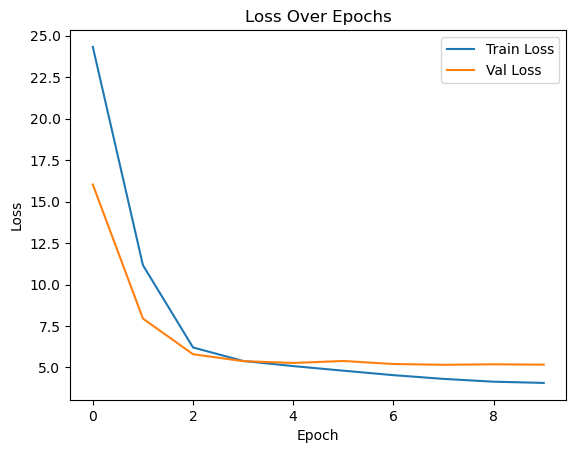

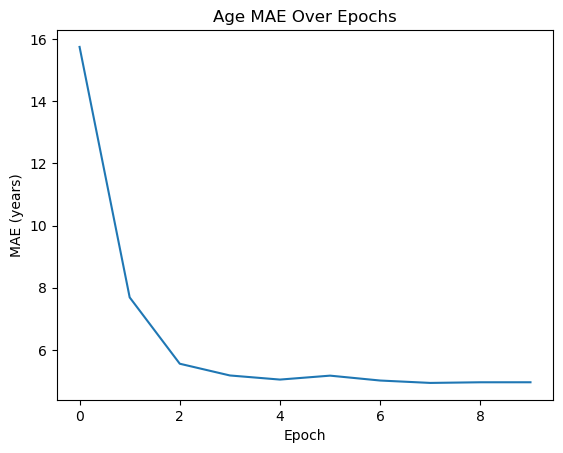

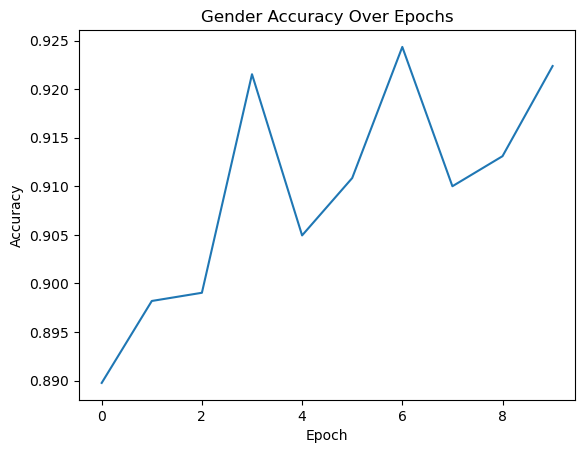

In [31]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"], label="Val Gender Acc")
plt.title("Gender Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

We observe an elbow in loss at epoch 2 (quite early). Age MAE plateaus around 2, also relatively soon in the training. However, gender continues to improve as we train more epochs.

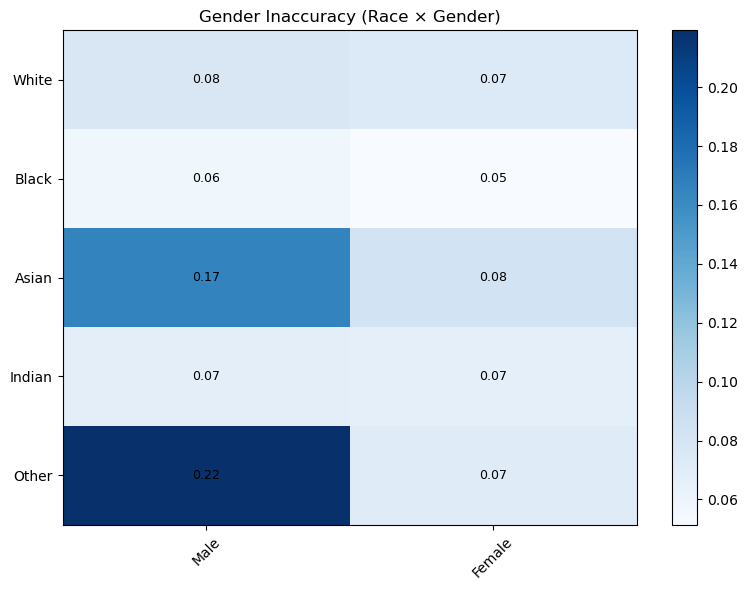

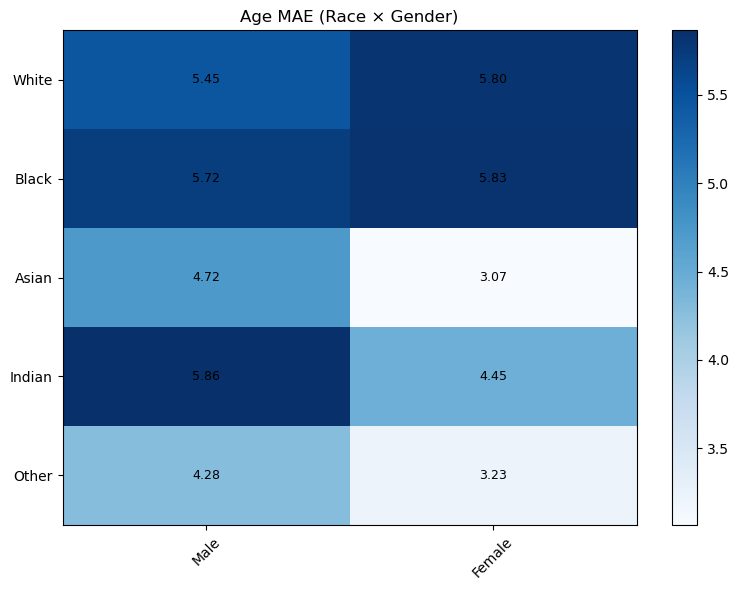

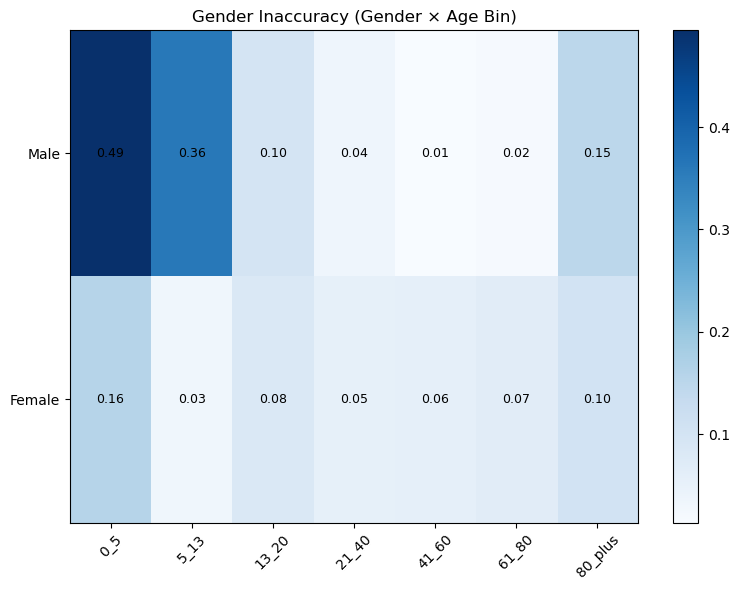

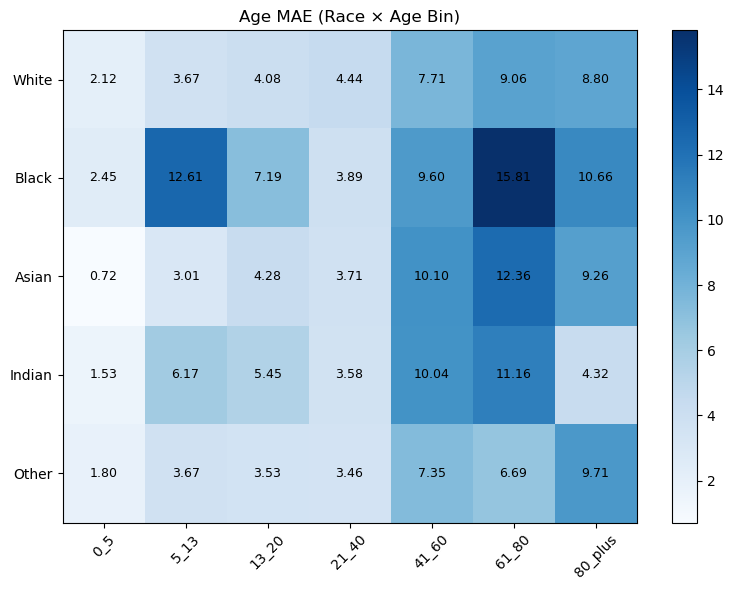

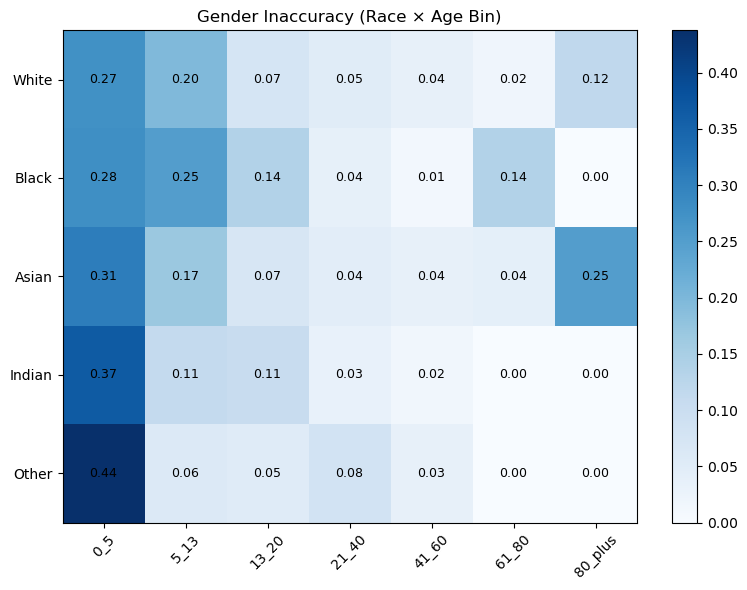

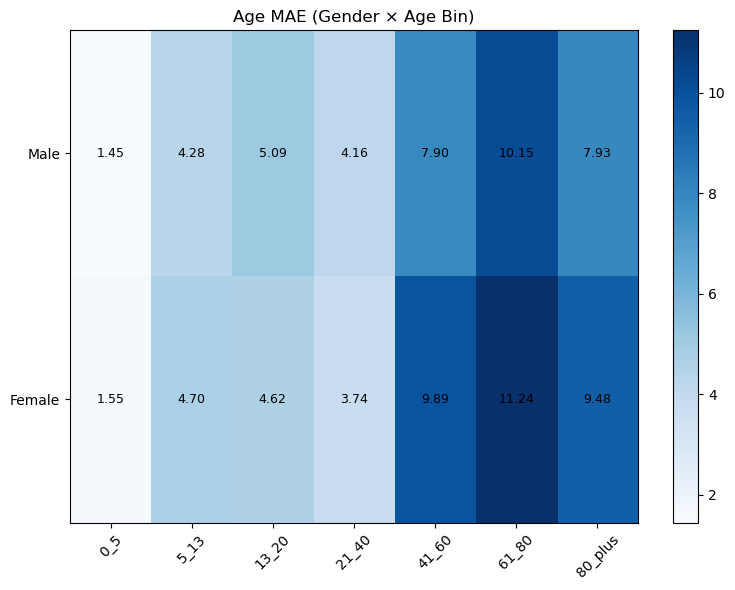

In [17]:
race_map = {
    "0": "White",
    "1": "Black",
    "2": "Asian",
    "3": "Indian",
    "4": "Other"
}

gender_map = {
    "0": "Male",
    "1": "Female"
}

age_order = ["0_5", "5_13", "13_20", "21_40", "41_60", "61_80", "80_plus"]
race_order = ["White", "Black", "Asian", "Indian", "Other"] 
gender_order = ["Male", "Female"]

# =========================================================
# 1. GET TEST PREDICTIONS
# =========================================================

def get_test_predictions(model, loader, device):
    model.eval()
    results = []

    with torch.no_grad():
        for images, ages, genders, races, age_bins in loader:
            images = images.to(device)

            age_pred, gender_logit = model(images)

            gender_prob = torch.sigmoid(gender_logit)
            gender_pred = (gender_prob >= 0.5).float()

            for i in range(len(images)):
                g = str(int(genders[i].item()))
                r = str(races[i])

                results.append({
                    "true_age": ages[i].item(),
                    "pred_age": age_pred[i].item(),
                    "age_error": age_pred[i].item() - ages[i].item(),

                    "true_gender": gender_map[g],
                    "pred_gender": gender_map[str(int(gender_pred[i].item()))],
                    "gender_correct": int(gender_pred[i].item() == genders[i].item()),

                    "race": race_map[r],
                    "age_bin": str(age_bins[i])
                })

    return pd.DataFrame(results)


# =========================================================
# 2. GROUP METRICS (MULTI-TASK)
# =========================================================

def compute_group_metrics(df, group_cols):
    grouped = df.groupby(group_cols)
    out = {}

    for name, sub in grouped:
        out[name] = {
            "gender_acc": sub["gender_correct"].mean(),
            "age_mae": np.abs(sub["age_error"]).mean(),
            "count": len(sub)
        }

    return out


# =========================================================
# 3. CONVERT TO HEATMAP MATRIX
# =========================================================

def to_matrix(metric_dict, row_name, col_name, value_key):
    rows = []

    for k, v in metric_dict.items():
        if not isinstance(k, tuple):
            k = (k,)
        rows.append((*k, v[value_key]))

    df = pd.DataFrame(rows, columns=[row_name, col_name, "value"])
    return df.pivot(index=row_name, columns=col_name, values="value")

def reorder_matrix(matrix, row_order=None, col_order=None):
    if row_order is not None:
        matrix = matrix.reindex(row_order)

    if col_order is not None:
        matrix = matrix.reindex(columns=col_order)

    return matrix
    
# =========================================================
# 4. HEATMAP PLOTTING
# =========================================================

def plot_heatmap(matrix, title, cmap="Blues"):

    plt.figure(figsize=(8, 6))

    # optional but recommended: consistent scaling per plot
    vmin = np.nanmin(matrix.values)
    vmax = np.nanmax(matrix.values)

    im = plt.imshow(matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    plt.title(title)
    plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=45)
    plt.yticks(range(len(matrix.index)), matrix.index)

    # numeric annotations
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.iloc[i, j]
            if not np.isnan(val):
                plt.text(
                    j, i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=9
                )

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

# =========================================================
# 5. TEST RESULTS
# =========================================================

test_results = get_test_predictions(resnet_model, test_loader, device)


# =========================================================
# 6. COMPUTE INTERSECTIONAL GROUPS
# =========================================================

race_gender = compute_group_metrics(test_results, ["race", "true_gender"])
race_age = compute_group_metrics(test_results, ["race", "age_bin"])
gender_age = compute_group_metrics(test_results, ["true_gender", "age_bin"])


# =========================================================
# 7. BUILD MATRICES
# =========================================================

rg_acc = to_matrix(race_gender, "race", "gender", "gender_acc")
rg_mae = to_matrix(race_gender, "race", "gender", "age_mae")

ra_acc = to_matrix(race_age, "race", "age_bin", "gender_acc")
ra_mae = to_matrix(race_age, "race", "age_bin", "age_mae")

ga_acc = to_matrix(gender_age, "true_gender", "age_bin", "gender_acc")
ga_mae = to_matrix(gender_age, "true_gender", "age_bin", "age_mae")

rg_inacc = 1 - rg_acc
ra_inacc = 1 - ra_acc
ga_inacc = 1 - ga_acc

rg_acc = reorder_matrix(rg_acc, race_order, gender_order)
rg_mae = reorder_matrix(rg_mae, race_order, gender_order)
rg_inacc = reorder_matrix(rg_inacc, race_order, gender_order)
ra_acc = reorder_matrix(ra_acc, race_order, age_order)
ra_mae = reorder_matrix(ra_mae, race_order, age_order)
ra_inacc = reorder_matrix(ra_inacc, race_order, age_order)
ga_acc = reorder_matrix(ga_acc, gender_order, age_order)
ga_mae = reorder_matrix(ga_mae, gender_order, age_order)
ga_inacc = reorder_matrix(ga_inacc, gender_order, age_order)

# =========================================================
# 8. PLOTS (6 TOTAL)
# =========================================================

plot_heatmap(rg_inacc, "Gender Inaccuracy (Race × Gender)")
plot_heatmap(rg_mae, "Age MAE (Race × Gender)")

plot_heatmap(ga_inacc, "Gender Inaccuracy (Gender × Age Bin)")
plot_heatmap(ra_mae, "Age MAE (Race × Age Bin)")

plot_heatmap(ra_inacc, "Gender Inaccuracy (Race × Age Bin)")
plot_heatmap(ga_mae, "Age MAE (Gender × Age Bin)")

In [ ]:
### EDA with ResNet Embeddings

In [38]:
# embeddings
X = emb_outputs["embeddings"].numpy()

# labels
race = np.array(emb_outputs["race"])
gender = np.array(emb_outputs["gender"])
age_bin = np.array(emb_outputs["age_bin"])

#defines how umap will compress our embeddings
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X)

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}

gender_map = {
    0.0: "Male",
    1.0: "Female"
}

def plot_umap(X_umap, labels, label_map=None, title=""):
    plt.figure(figsize=(7,6))

    labels = np.array(labels)
    try:
        labels = labels.astype(int)
    except:
        pass

    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab

        name = label_map[lab] if label_map else str(lab)

        plt.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            label=name,
            alpha=0.6
        )

    plt.title(title)
    plt.legend()
    plt.show()

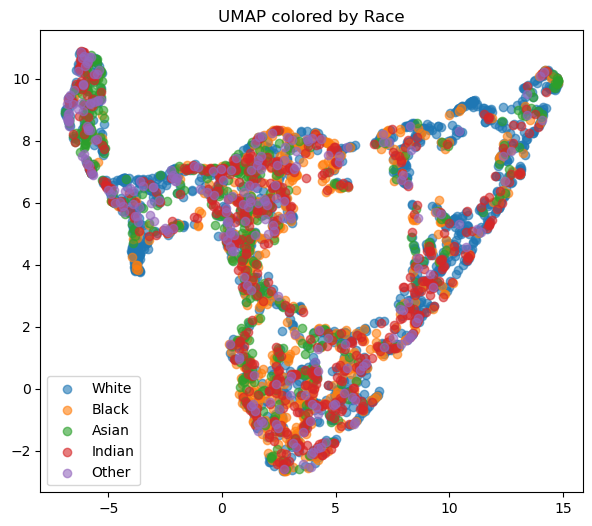

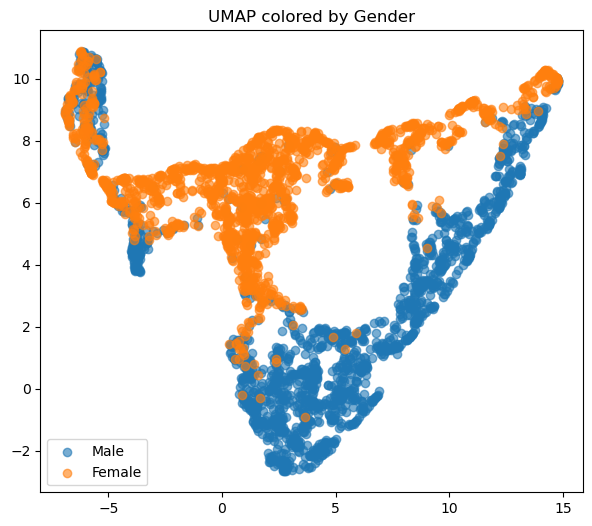

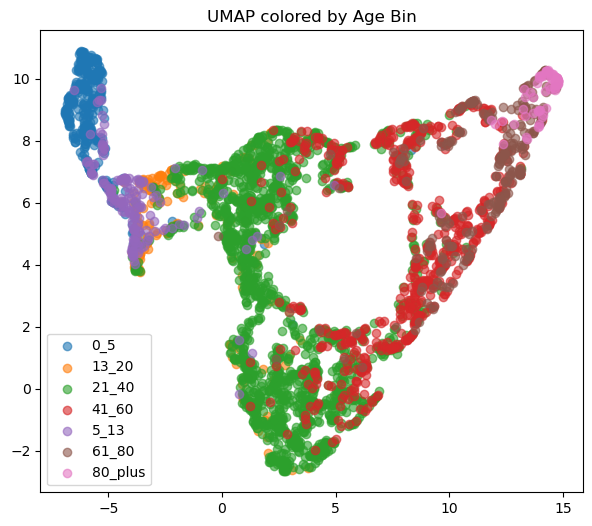

In [39]:
plot_umap(X_umap, race, race_map, "UMAP colored by Race")
plot_umap(X_umap, gender, gender_map, "UMAP colored by Gender")
plot_umap(X_umap, age_bin, None, "UMAP colored by Age Bin")

In [ ]:
### INTERSECTIONAL REWEIGHTING

In [14]:
from torch.utils.data import WeightedRandomSampler

# build combined sensitive group
race = train_df["race"].astype(str).values
gender = train_df["gender"].astype(str).values
age_bin = train_df["eval_age_bin"].astype(str).values

groups = race + "_" + gender + "_" + age_bin

# compute frequencies
unique_groups, counts = np.unique(groups, return_counts=True)
group_freq = dict(zip(unique_groups, counts))

# inverse frequency weighting
sample_weights = np.array([1.0 / group_freq[g] for g in groups])

# normalize (stability)
sample_weights = sample_weights / sample_weights.sum()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler,
    num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_reweighted_model = MultiTaskResNet().to(device)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(resnet_reweighted_model.parameters(), lr=1e-4)

num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": [],
    "race_gap": []  
}

best_val_mae = float("inf")
best_gender_acc = 0.0

start_time = time.time()


# =========================
# TRAINING LOOP
# =========================
print("Starting training loop...")
for epoch in range(num_epochs):
    print("Epoch started")

    # ---- train ----
    train_metrics = train_one_epoch(
        resnet_reweighted_model, train_loader, optimizer,
        age_criterion, gender_criterion, device
    )

    # ---- validate ----
    val_metrics = evaluate(
        resnet_reweighted_model, val_loader,
        age_criterion, gender_criterion, device
    )

    # ---- log history ----
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_age_mae"].append(val_metrics["age_mae"])
    history["val_gender_acc"].append(val_metrics["gender_acc"])

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_metrics['loss']:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Age MAE: {val_metrics['age_mae']:.2f} | "
          f"Gender Acc: {val_metrics['gender_acc']:.3f}")

    # ---- save best model ----
    if (val_metrics["age_mae"] < best_val_mae or
        (abs(val_metrics["age_mae"] - best_val_mae) < 1e-4 and
         val_metrics["gender_acc"] > best_gender_acc)):

        best_val_mae = val_metrics["age_mae"]
        best_gender_acc = val_metrics["gender_acc"]

        torch.save(resnet_reweighted_model.state_dict(), "best_resnet.pt")
        print("  → Saved new best model")

# =========================
# SAVE FINAL MODEL + HISTORY
# =========================
torch.save({
    "model_state": resnet_reweighted_model.state_dict(),
    "history": history,
    "config": {
        "img_size": IMG_SIZE
    }
}, "resnet_checkpoint.pt")


end_time = time.time()
print(f"\nTraining time: {(end_time - start_time)/60:.2f} minutes")

Starting training loop...
Epoch started


Training: 100%|██████████| 260/260 [00:51<00:00,  5.05it/s]


Epoch 01 | Train Loss: 29.8055 | Val Loss: 16.7990 | Age MAE: 16.53 | Gender Acc: 0.900
  → Saved new best model
Epoch started


Training: 100%|██████████| 260/260 [00:44<00:00,  5.88it/s]


Epoch 02 | Train Loss: 16.7484 | Val Loss: 9.9511 | Age MAE: 9.64 | Gender Acc: 0.861
  → Saved new best model
Epoch started


...

Epoch 08 | Train Loss: 3.5345 | Val Loss: 5.5545 | Age MAE: 5.34 | Gender Acc: 0.922
  → Saved new best model
Epoch started


Training: 100%|██████████| 260/260 [00:47<00:00,  5.43it/s]


Epoch 09 | Train Loss: 3.2392 | Val Loss: 5.7304 | Age MAE: 5.50 | Gender Acc: 0.913
Epoch started


Training: 100%|██████████| 260/260 [00:50<00:00,  5.15it/s]


Epoch 10 | Train Loss: 3.1432 | Val Loss: 5.4926 | Age MAE: 5.26 | Gender Acc: 0.926
  → Saved new best model

Training time: 9.30 minutes


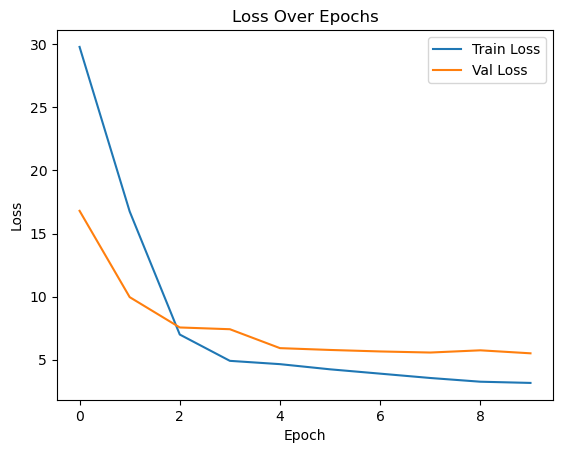

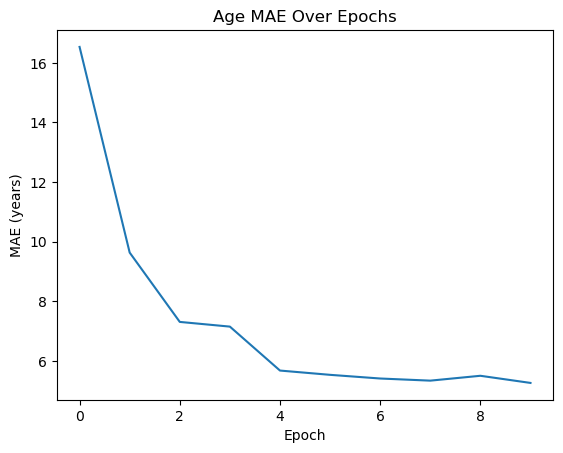

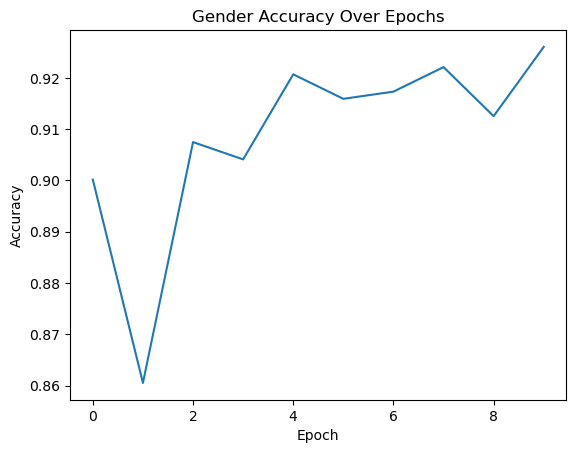

In [15]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"], label="Val Gender Acc")
plt.title("Gender Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [23]:
test_results = get_test_predictions(resnet_reweighted_model, test_loader, device)
fairness_report = compute_all_fairness(test_results)

race_map = {"0":"White","1":"Black","2":"Asian","3":"Indian","4":"Other"}
gender_map = {"0":"Male","1":"Female"}

# -------------------------
# EXTRACT 
# -------------------------
race_per_group = normalize(race_metrics)
gender_per_group = normalize(gender_metrics)
age_per_group = normalize(age_metrics)

# -------------------------
# DEBUG PRINT 
# -------------------------
print("Race keys:", race_per_group.keys())
print("Gender keys:", gender_per_group.keys())
print("Age keys:", age_per_group.keys())

# -------------------------
# PLOTS
# -------------------------
plot_metrics(race_per_group, "Race Fairness Metrics", race_map)
plot_metrics(gender_per_group, "Gender Fairness Metrics", gender_map)
plot_metrics(age_per_group, "Age-Bin Fairness Metrics")

NameError: name 'race_metrics' is not defined